# Notebook 2: Spectral Exploration
This notebook aims to answer the following question:

> Which wavelengths appear informative, and how were reduced band sets selected?

## 0. Imports

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.morphology import binary_opening, binary_closing, remove_small_objects, disk

import warnings
warnings.filterwarnings('ignore')

from hsi_utils import load_data, load_cube, build_foreground_mask

from scipy.signal import find_peaks

from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import make_pipeline

import math


In [2]:
train_files, _, _, files_split = load_data()

 Mounting E: into /mnt/e ...
[OK] Found dataset: /mnt/e/HSI_Dataset_2/Elements/data
 Removing old link /home/isaacmuscat/Grain-Variety-Classification/data_external
[OK] Linked /home/isaacmuscat/Grain-Variety-Classification/data_external -> /mnt/e/HSI_Dataset_2/Elements/data
Sample files:
   raw/calibration/FX10/calibration_1705a_0.hdf5
   raw/calibration/FX10/calibration_1705a_1.hdf5
   raw/calibration/FX10/calibration_1705a_2.hdf5
   raw/calibration/FX10/calibration_1705a_3.hdf5
   raw/calibration/FX10/calibration_1705_0.hdf5
   raw/calibration/FX10/calibration_1705_1.hdf5
   raw/calibration/FX10/calibration_1705_2.hdf5
   raw/calibration/FX10/calibration_1705_3.hdf5
   raw/calibration/Snapshot/processed/calibration_1705a_0/image_0000000003.hdr
   raw/calibration/Snapshot/processed/calibration_1705a_1/image_0000000000.hdr
ROOT:     /mnt/e/HSI_Dataset_2/Elements/data
Basepath: /mnt/e/HSI_Dataset_2/Elements/data/raw/FX10
OUTDIR:   /mnt/e/HSI_Dataset_2/Elements/data/processed/quickrun
To

## 1. Load data with LoadHSI (no dark/white correction)

In [3]:
# --- Load cached grain spectra with image-level split ---
CACHE_PATH = "cached_pixel_spectra_image_split_v1.npz"

data = np.load(CACHE_PATH, allow_pickle=True)

X_all_raw = data["X_all_raw"]
y_all = data["y_all"]
image_id_all = data["image_id_all"]
split_all = data["split_all"]
size_all = data["size_all"]
wlens = data["wlens"]
varieties = list(data["varieties"])

wavelengths = wlens

print("X_all_raw shape:", X_all_raw.shape)
print("y_all shape:", y_all.shape)
print("Loaded varieties:", varieties)

print("\nPixels per split:")
print(pd.Series(split_all).value_counts())

print("\nImages per split:")
print(pd.DataFrame({
    "image": image_id_all,
    "split": split_all
}).drop_duplicates().groupby("split").size())

X_all_raw shape: (45000, 224)
y_all shape: (45000,)
Loaded varieties: ['barley', 'corn', 'flax']

Pixels per split:
train    27000
valid     9000
test      9000
Name: count, dtype: int64

Images per split:
split
test      9
train    27
valid     9
dtype: int64


## 2. Preprocessing: mean centering


Mean of centered data: 3.68e-08


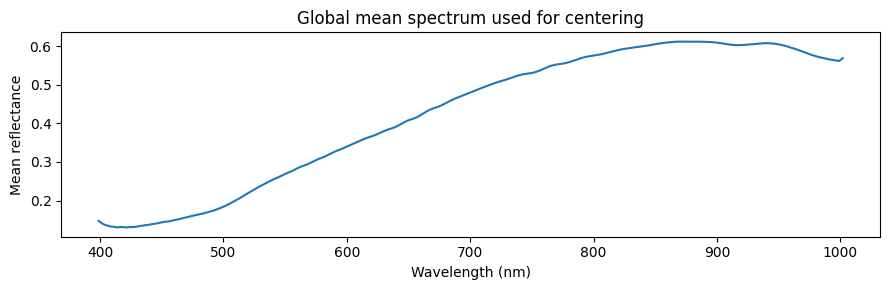

In [4]:
# --- Mean-center data - simply for exploratory analysis ---
global_mean = X_all_raw.mean(axis=0)

X_all_mc = X_all_raw - global_mean

print("Mean of centered data:", X_all_mc.mean(axis=0).mean().round(10))

plt.figure(figsize=(9, 3))
plt.plot(wavelengths, global_mean)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean reflectance")
plt.title("Global mean spectrum used for centering")
plt.tight_layout()
plt.show()

* Mean-centres spectral data by subtracting the global mean spectrum from every pixel spectrum. 
* Mean-centering is important for PCA as it ensures the directions of the max. variance are relative to the origin (the data mean). 
* The plotted global mean spectrum also provides a useful summary of the average reflectance pattern across all sampled grain pixels.

This is primarily for visualization, not the final predictive validation. This is because for that we will be looking into train-set centering preferibally.

## 3. PCA - component selection via variance explained (scree plot)

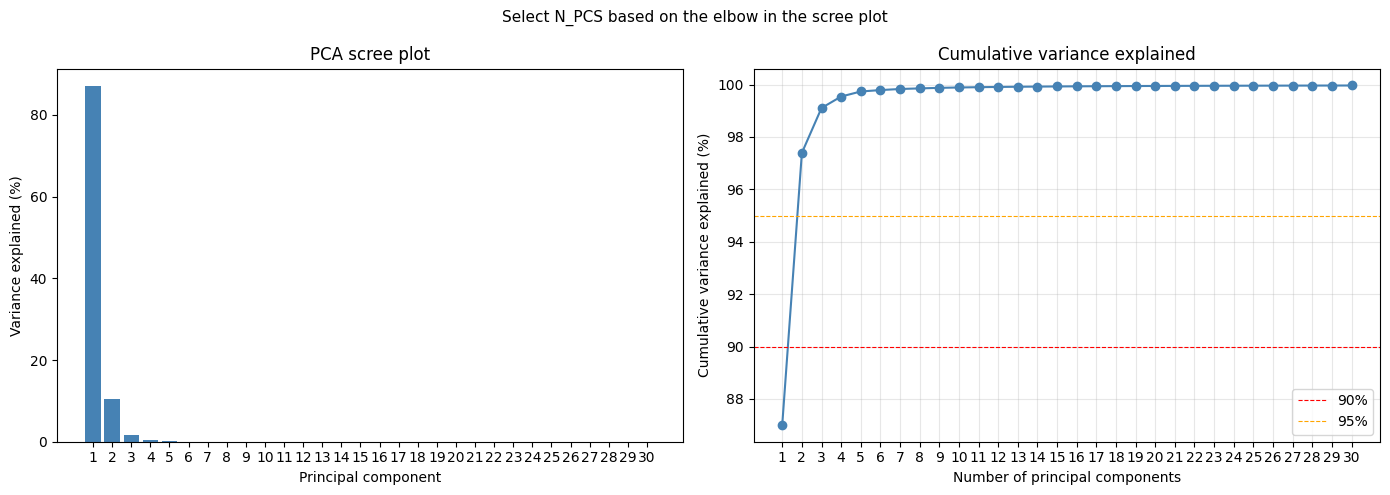

  PC 1: 87.01%  (cumulative: 87.0%)
  PC 2: 10.38%  (cumulative: 97.4%)
  PC 3: 1.71%  (cumulative: 99.1%)
  PC 4: 0.44%  (cumulative: 99.5%)
  PC 5: 0.19%  (cumulative: 99.7%)
  PC 6: 0.05%  (cumulative: 99.8%)
  PC 7: 0.04%  (cumulative: 99.8%)
  PC 8: 0.02%  (cumulative: 99.9%)
  PC 9: 0.02%  (cumulative: 99.9%)
  PC10: 0.01%  (cumulative: 99.9%)
  PC11: 0.01%  (cumulative: 99.9%)
  PC12: 0.01%  (cumulative: 99.9%)
  PC13: 0.01%  (cumulative: 99.9%)
  PC14: 0.01%  (cumulative: 99.9%)
  PC15: 0.01%  (cumulative: 99.9%)


In [5]:
_, S, Vt = np.linalg.svd(X_all_mc, full_matrices=False) # S -> importance of each PC, Vt -> how does each PC look (loadings)

var_exp = (S**2) / (S**2).sum() # singular values -> proportions
cumvar  = np.cumsum(var_exp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 31), var_exp[:30] * 100, color='steelblue')
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("PCA scree plot")
axes[0].set_xticks(range(1, 31))

# Cumulative variance
axes[1].plot(range(1, 31), cumvar[:30] * 100, 'o-', color='steelblue')
axes[1].axhline(90, color='red', linestyle='--', linewidth=0.8, label='90%')
axes[1].axhline(95, color='orange', linestyle='--', linewidth=0.8, label='95%')
axes[1].set_xlabel("Number of principal components")
axes[1].set_ylabel("Cumulative variance explained (%)")
axes[1].set_title("Cumulative variance explained")
axes[1].legend()
axes[1].set_xticks(range(1, 31))
axes[1].grid(True, alpha=0.3)

plt.suptitle("Select N_PCS based on the elbow in the scree plot", fontsize=11)
plt.tight_layout()
plt.show()

for i in range(15):
    print(f"  PC{i+1:2d}: {var_exp[i]*100:.2f}%  (cumulative: {cumvar[i]*100:.1f}%)")



* PCA using singular value decomposition and calculates the percentage of variance explained by each principal component. 
* Scree plot shows how much variation is captured by each component
* Cumulative variance plot shows how many components are needed to explain most of the spectral variability.
* Number of retained components is chosen by looking for the point where additional components contribute only small extra amounts of variance.

In [6]:
N_PCS = 3   # set based on visual inspection of the scree plot

## 4. PCA scores and loadings

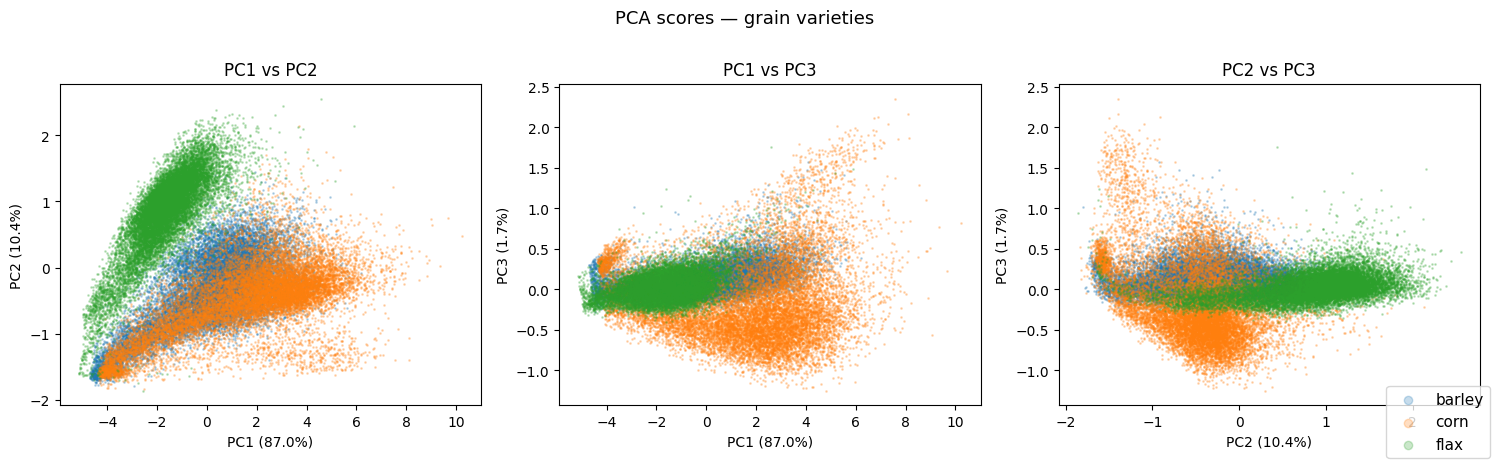

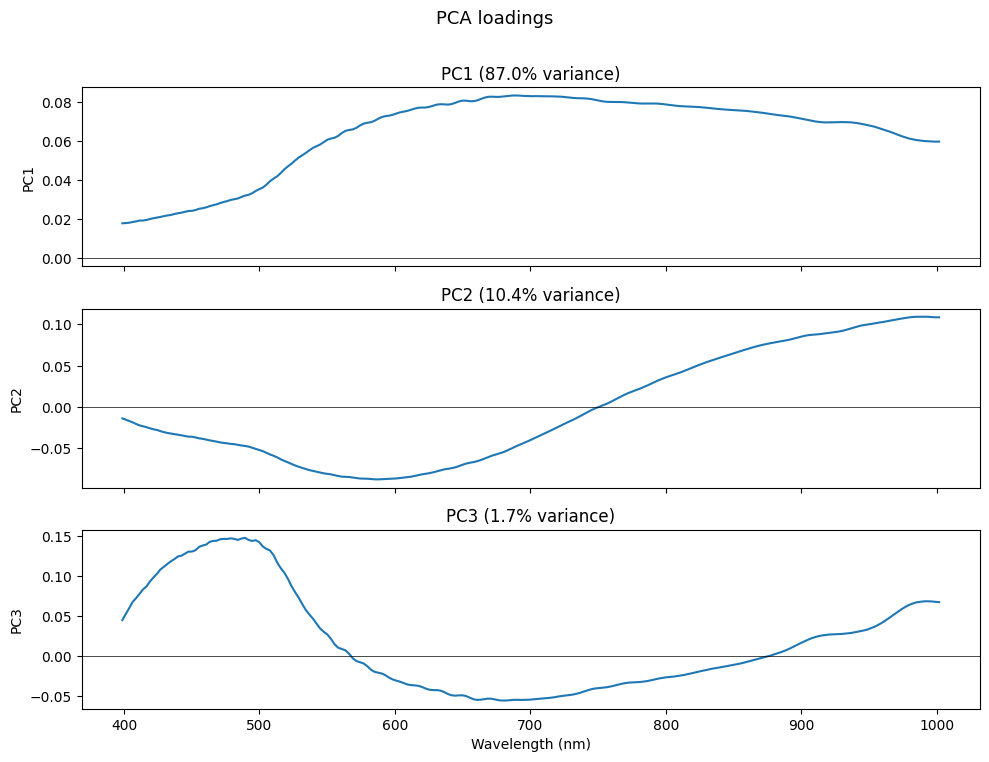

In [7]:
# --- PCA scores and loadings without outlier removal ---

var_explained = (S**2) / (S**2).sum() # how much var each PC explains

loadings = Vt[:N_PCS, :] # take first 3 loading vectors
scores_all = X_all_mc @ loadings.T # project spectra onto PCs (where each sampled pixel lies on PCA space)

pairs = [(i, j) for i in range(N_PCS) for j in range(i + 1, N_PCS)] # all possible PC pairs
ncols = 3
nrows = int(np.ceil(len(pairs) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = np.array(axes).ravel()

for ax, (i, j) in zip(axes, pairs): # plot PCA scores for each class
    for var in varieties:
        mask = y_all == var # select only pixels from that class
        ax.scatter(
            scores_all[mask, i],
            scores_all[mask, j],
            s=1,
            alpha=0.25,
            label=var
        )

    ax.set_xlabel(f"PC{i+1} ({var_explained[i]*100:.1f}%)")
    ax.set_ylabel(f"PC{j+1} ({var_explained[j]*100:.1f}%)")
    ax.set_title(f"PC{i+1} vs PC{j+1}")

for ax in axes[len(pairs):]:
    ax.set_visible(False)

handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, markerscale=6, loc="lower right", fontsize=11)

plt.suptitle("PCA scores — grain varieties", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


# --- PCA loadings ---

fig, axes = plt.subplots(N_PCS, 1, figsize=(10, 2.5 * N_PCS), sharex=True)

if N_PCS == 1:
    axes = [axes]

for i, ax in enumerate(axes): # loadings plot
    ax.plot(wavelengths, loadings[i])
    ax.axhline(0, color="k", linewidth=0.5)
    ax.set_ylabel(f"PC{i+1}")
    ax.set_title(f"PC{i+1} ({var_explained[i]*100:.1f}% variance)")

axes[-1].set_xlabel("Wavelength (nm)")

plt.suptitle("PCA loadings", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

* Plots PCA scores and loadings. The score plots show how the sampled pixels are positioned in the reduced PCA space and whether the grain varieties form separate clusters.
* Clear separation between varieties suggests that their spectra differ. 
* Loading plots show which wavelength regions contribute most strongly to each principal component - which features are responsible for variation between samples?
* PC1 - high 600s wavelengths are the most positive - matter most; PC2 - around 600 most negative, then towards high 900s most positive; PC3 - high 400s most positive


--- PC score images for barley ---


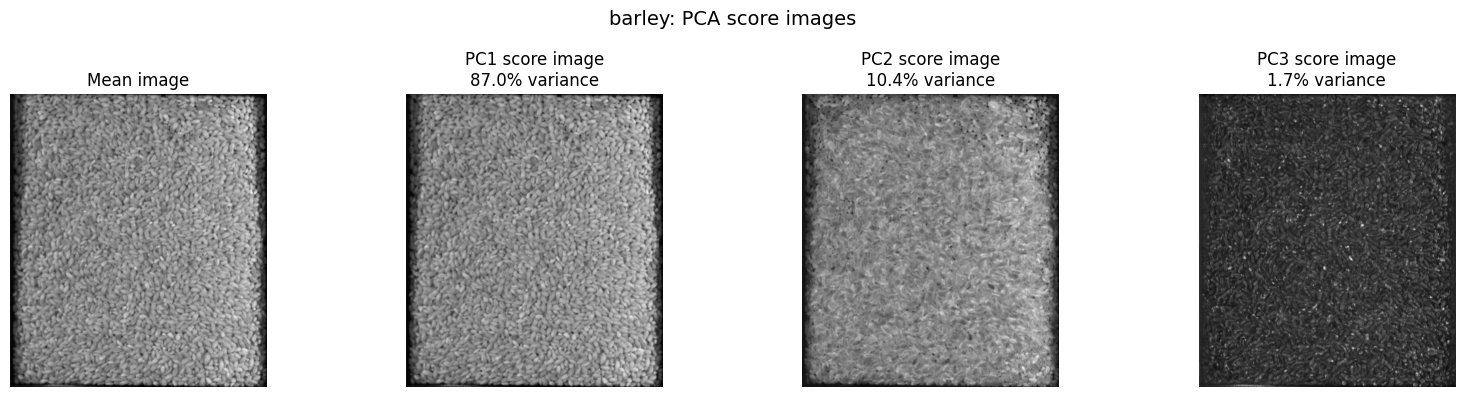


--- PC score images for corn ---


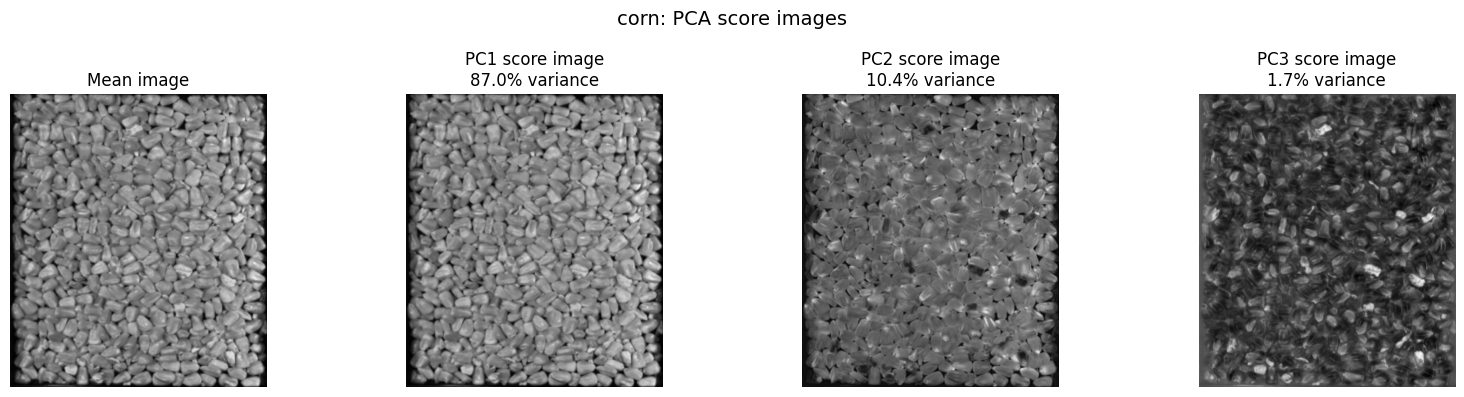


--- PC score images for flax ---


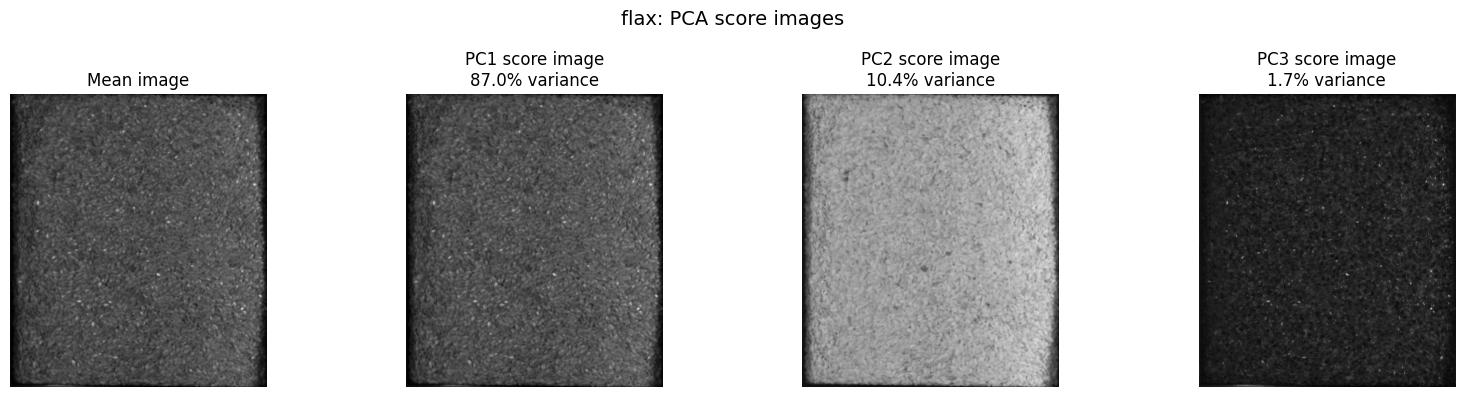

In [8]:
# --- PC score images for one example hypercube ---

def compute_pc_score_images(hcube, global_mean, loadings):
    """
    Project every pixel spectrum in a hyperspectral cube onto the PCA loadings,
    then reshape the resulting PC scores back into image form.
    """

    h, w, b = hcube.shape

    # Flatten image into pixel spectra: (height*width, bands)
    X_img = hcube.reshape(-1, b)

    # Apply same mean centering used for PCA
    X_img_mc = X_img - global_mean

    # Project onto PCA loadings
    scores_img = X_img_mc @ loadings.T

    # Reshape back to image format: (height, width, PCs)
    score_images = scores_img.reshape(h, w, loadings.shape[0])

    return score_images


# Choose one example image per variety
for var in varieties:
    print(f"\n--- PC score images for {var} ---")

    subset = train_files[train_files["variety"] == var]

    if subset.empty:
        print(f"No samples found for {var}")
        continue

    row = subset.iloc[0]
    filepath = row["filepath_FX10"]

    hcube, wlens, darkref, whiteref = load_cube(filepath)

    # Use the same preprocessing/cropping as used for the PCA dataset
    # If keeping all spectral bands, use:
    hcube_c = hcube[50:1050, 50:925, :]
    wlens_c = wlens

    # If your PCA dataset used 20:200 spectral crop, use this instead:
    # hcube_c = hcube[50:1050, 50:925, 20:200]
    # wlens_c = wlens[20:200]

    # Safety check
    if hcube_c.shape[2] != len(global_mean):
        raise ValueError(
            f"Band mismatch: hcube has {hcube_c.shape[2]} bands, "
            f"but PCA mean/loadings expect {len(global_mean)} bands. "
            "Make sure the spectral cropping matches the PCA dataset."
        )

    score_images = compute_pc_score_images(
        hcube_c,
        global_mean=global_mean,
        loadings=loadings
    )

    mean_img = np.mean(hcube_c, axis=2)

    n_pcs_to_show = min(N_PCS, 6)

    fig, axes = plt.subplots(
        1,
        n_pcs_to_show + 1,
        figsize=(4 * (n_pcs_to_show + 1), 4)
    )

    axes[0].imshow(mean_img, cmap="gray")
    axes[0].set_title("Mean image")
    axes[0].axis("off")

    for i in range(n_pcs_to_show):
        pc_img = score_images[:, :, i]

        im = axes[i + 1].imshow(pc_img, cmap="gray")
        axes[i + 1].set_title(
            f"PC{i+1} score image\n{var_explained[i]*100:.1f}% variance"
        )
        axes[i + 1].axis("off")

    plt.suptitle(f"{var}: PCA score images", fontsize=14)
    plt.tight_layout()
    plt.show()

* The PCA score images provide a spatial interpretation of the PCs by projecting each pixel spectrum in the hyperspectral image onto the PCA space and reshaping the resulting scores back into image form.

* **PC1 (87.0% explained variance)** captures the dominant variation in the dataset and appears highly similar to the original mean image for all three grain types. This suggests that PC1 primarily represents overall spectral intensity or general brightness differences rather than fine discriminative structure. In other words, it captures the bulk of shared variation across the grain samples.

* **PC2 (10.4% explained variance)** highlights more subtle spatial variation not captured by PC1. For barley and corn, grain structures remain clearly visible, suggesting that this component captures additional spectral differences related to grain composition, texture, or reflectance behaviour. For flax, however, the image appears more uniform, indicating less internal spectral heterogeneity.

* **PC3 (1.7% explained variance)** captures only a small proportion of total variance and appears much noisier. Fine texture patterns sicj as edges are still somewhat visible for barley and corn, but the component is much less structured and may partly reflect minor variation or noise rather than strong discriminative information.

* The results suggest that most meaningful spectral information is concentrated in the first two principal components. Barley and corn exhibit stronger internal structural variation across PCs, whereas flax appears more spectrally homogeneous, which may help explain why flax is often easier to separate in classification experiments.

* Overall, these score images align with the PCA variance breakdown, showing that the dominant discriminatory information is likely contained in the first and perhaps second PCs, supporting the use of PCA loadings from these components for wavelength selection.


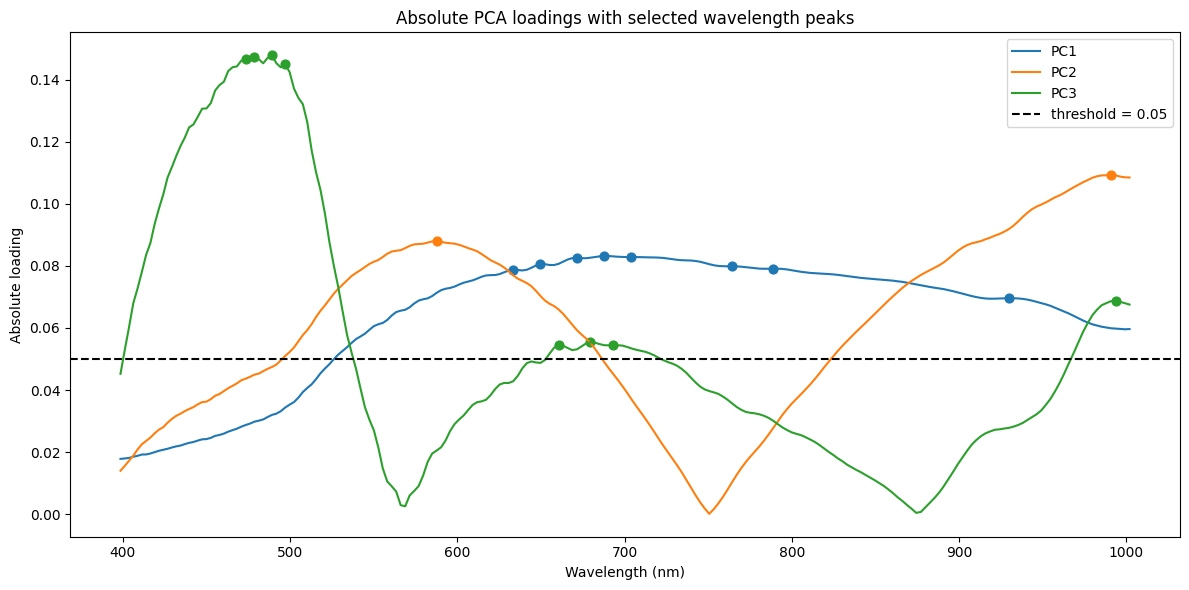

PC1 selected wavelengths: [633.5 649.8 671.5 687.8 704.2 764.3 789.  929.7]
PC2 selected wavelengths: [587.7 990.7]
PC3 selected wavelengths: [473.6 478.8 489.3 497.2 660.6 679.6 693.3 993.5]


In [9]:
# --- PCA loading-based wavelength selection ---
N_LOADINGS = N_PCS   # inspecting first few PCs
loading_threshold = 0.05     # may need adjustment; going off of source from plum paper

selected_bands = {}

plt.figure(figsize=(12, 6))

for pc in range(N_LOADINGS):
    abs_loading = np.abs(loadings[pc])

    peaks, properties = find_peaks(
        abs_loading,
        height=loading_threshold
    )

    selected_bands[f"PC{pc+1}"] = wavelengths[peaks]

    plt.plot(
        wavelengths,
        abs_loading,
        label=f"PC{pc+1}"
    )

    plt.scatter(
        wavelengths[peaks],
        abs_loading[peaks],
        s=40
    )

plt.axhline(
    loading_threshold,
    linestyle="--",
    color="black",
    label=f"threshold = {loading_threshold}"
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Absolute loading")
plt.title("Absolute PCA loadings with selected wavelength peaks")
plt.legend()
plt.tight_layout()
plt.show()

for pc, wl in selected_bands.items():
    print(pc, "selected wavelengths:", np.round(wl, 1))

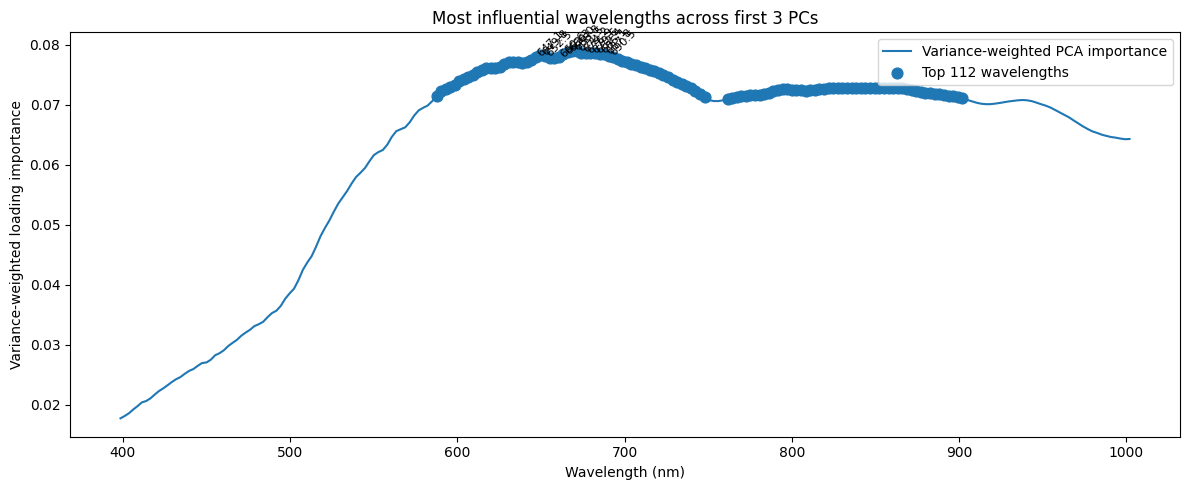

Top selected wavelengths:
[668.8 671.5 666.  674.2 679.6 676.9 682.4 685.1 687.8 663.3 649.8 690.5
 652.5 647.1 660.6 693.3 655.2 657.9 696.  644.4 698.7 633.5 630.8 636.2
 641.6 701.4 638.9 704.2 628.1 706.9 625.4 709.6 620.  617.3 622.7 712.4
 614.6 715.1 717.8 611.9 720.5 609.2 723.3 606.5 726.  603.8 728.7 601.1
 731.5 734.2 598.4 736.9 595.7 857.8 860.6 855.  827.5 830.3 824.8 852.3
 863.3 833.  849.5 866.1 835.8 822.  739.7 846.8 838.5 844.  841.3 593.1
 819.2 868.8 797.2 794.5 816.5 800.  871.6 813.8 802.8 791.8 805.5 811.
 808.2 742.4 874.4 590.4 789.  877.1 879.9 786.3 882.6 745.2 885.4 783.5
 888.2 780.8 890.9 778.  775.3 772.6 893.7 587.7 769.8 896.5 767.1 747.9
 899.2 764.3 902.  761.6]
Top selected band indices:
[102 103 101 104 106 105 107 108 109 100  95 110  96  94  99 111  97  98
 112  93 113  89  88  90  92 114  91 115  87 116  86 117  84  83  85 118
  82 119 120  81 121  80 122  79 123  78 124  77 125 126  76 127  75 171
 172 170 160 161 159 169 173 162 168 174 163 1

In [10]:
# --- Variance-weighted PCA loading importance across PCs ---

# Use all PCs currently retained in the PCA analysis
N_LOADINGS = N_PCS

# Absolute PCA loadings for selected PCs
abs_loadings = np.abs(loadings[:N_LOADINGS, :])

# Use the explained variance of each PC as its weight
explained_weights = var_explained[:N_LOADINGS]

# Weighted importance: PCs explaining more variance contribute more
band_importance = (abs_loadings * explained_weights[:, np.newaxis]).sum(axis=0)

# Rank all bands from most to least important
ranked_band_indices = np.argsort(band_importance)[::-1]

# Select top wavelengths for visualisation
top_k = 112
top_idx = ranked_band_indices[:top_k]
top_wavelengths = wavelengths[top_idx]

plt.figure(figsize=(12, 5))
plt.plot(wavelengths, band_importance, label="Variance-weighted PCA importance")
plt.scatter(
    top_wavelengths,
    band_importance[top_idx],
    s=60,
    label=f"Top {top_k} wavelengths"
)

for wl, val in zip(top_wavelengths[:15], band_importance[top_idx][:15]):
    plt.text(wl, val, f"{wl:.1f}", fontsize=8, rotation=45)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Variance-weighted loading importance")
plt.title(f"Most influential wavelengths across first {N_LOADINGS} PCs")
plt.legend()
plt.tight_layout()
plt.show()

print("Top selected wavelengths:")
print(np.round(top_wavelengths, 1))

print("Top selected band indices:")
print(top_idx)

The PCA score plots show whether grain varieties separate in reduced spectral space. 

When a PC separates one or more varieties, the corresponding loading plot is inspected to identify which wavelengths contribute most strongly to that separation. 

Peaks in the absolute loading values indicate wavelengths that explain a large share of the spectral variation represented by that PC. These wavelengths can then be compared with the mean spectra of the varieties and considered as candidate bands for reduced-band classification or CNN input.

Remember - let's look back at the mean spectra plot from before:

<p align="center">
    <img src="meanspectra.png" width="800">
</p>

The wavelengths with high PC1 loadings -> in this case [617.3 630.8 649.8 668.8] -> correspond to regions where the mean spectra differ most clearly.

## VIP scores 

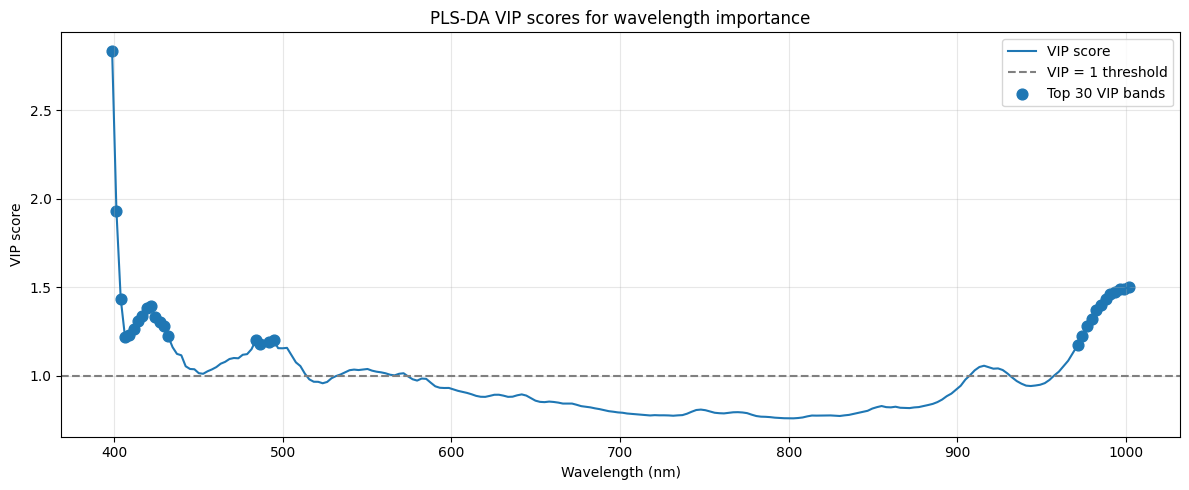

Top VIP wavelengths:
[ 398.8  401.3 1001.9  999.1  996.3  993.5  990.7  403.8  987.9  985.2
  421.7  419.2  982.4  416.6  424.3  979.6  414.1  426.9  429.5  976.8
  411.5  408.9  974.   432.   406.4  484.   494.6  491.9  486.7  971.3]

Number of wavelengths with VIP > 1:
86


In [ ]:
# --- Supervised band selection using PLS-DA VIP scores ---

from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelBinarizer

def compute_vip_scores(pls_model):
    """
    Compute Variable Importance in Projection scores for a fitted sklearn PLSRegression model.
    """
    T = pls_model.x_scores_        # scores: n_samples x n_components
    W = pls_model.x_weights_       # weights: n_features x n_components
    Q = pls_model.y_loadings_      # y loadings: n_targets x n_components

    p, h = W.shape

    # Amount of Y variance explained by each component
    s = np.sum(T**2, axis=0) * np.sum(Q**2, axis=0)

    total_s = np.sum(s)

    vip = np.sqrt(
        p * np.sum((W**2) * s, axis=1) / (total_s + 1e-12)
    )

    return vip


# Use train pixels only
train_mask = split_all == "train"

X_train_vip = X_all_raw[train_mask]
y_train_vip = y_all[train_mask]

lb_vip = LabelBinarizer()
Y_train_vip = lb_vip.fit_transform(y_train_vip)

# Mean-centering based on training pixels
X_train_vip_mean = X_train_vip.mean(axis=0)
X_train_vip_mc = X_train_vip - X_train_vip_mean

# number of PLS components for VIP calculation
N_COMPONENTS_VIP = 10

pls_vip = PLSRegression(
    n_components=N_COMPONENTS_VIP,
    max_iter=500
)

pls_vip.fit(X_train_vip_mc, Y_train_vip)

vip_scores = compute_vip_scores(pls_vip)

ranked_band_indices_vip = np.argsort(vip_scores)[::-1]

plt.figure(figsize=(12, 5))
plt.plot(wavelengths, vip_scores, label="VIP score")
plt.axhline(1.0, linestyle="--", color="gray", label="VIP = 1 threshold")

top_k = 30
top_idx_vip = ranked_band_indices_vip[:top_k]

plt.scatter(
    wavelengths[top_idx_vip],
    vip_scores[top_idx_vip],
    s=60,
    label=f"Top {top_k} VIP bands"
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("VIP score")
plt.title("PLS-DA VIP scores for wavelength importance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Top VIP wavelengths:")
print(np.round(wavelengths[top_idx_vip], 1))

print("\nNumber of wavelengths with VIP > 1:")
print(np.sum(vip_scores > 1))

## iPLS - Interval based selection

,interval_start_nm,interval_end_nm,n_bands,best_n_components,validation_accuracy
3,500,550,18,4,0.803556
4,550,600,19,9,0.768444
11,900,950,18,7,0.730000
6,650,700,18,7,0.726333
5,600,650,19,7,0.703778
8,750,800,18,6,0.703111
7,700,750,18,6,0.690444
10,850,900,18,10,0.684556
9,800,850,19,10,0.680778
2,450,500,20,7,0.679667


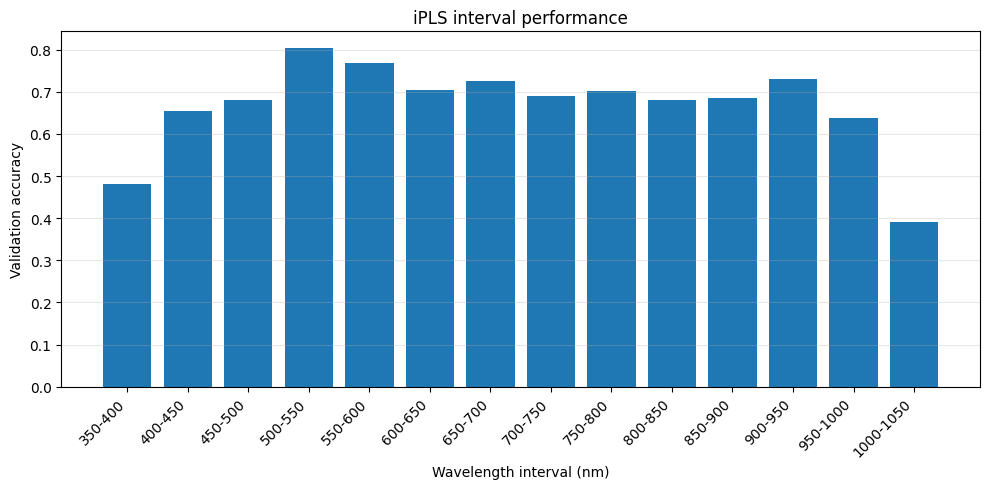

In [17]:
# --- Interval PLS-DA band selection (iPLS) ---

from sklearn.metrics import accuracy_score

def evaluate_plsda_band_subset(
    X_train,
    y_train,
    X_valid,
    y_valid,
    band_indices,
    max_components=15
):
    """
    Fits PLS-DA on a subset of bands and selects number of components by validation accuracy.
    Returns best validation accuracy and best component count.
    """
    Xtr = X_train[:, band_indices]
    Xva = X_valid[:, band_indices]

    train_mean = Xtr.mean(axis=0)

    Xtr_mc = Xtr - train_mean
    Xva_mc = Xva - train_mean

    lb_local = LabelBinarizer()
    Ytr = lb_local.fit_transform(y_train)

    max_comp_allowed = min(
        max_components,
        Xtr_mc.shape[1],
        Xtr_mc.shape[0] - 1
    )

    best_acc = -1
    best_n_comp = None

    for n_comp in range(1, max_comp_allowed + 1):
        pls = PLSRegression(
            n_components=n_comp,
            max_iter=500
        )

        pls.fit(Xtr_mc, Ytr)

        scores = pls.predict(Xva_mc)
        y_pred = lb_local.classes_[np.argmax(scores, axis=1)]

        acc = accuracy_score(y_valid, y_pred)

        if acc > best_acc:
            best_acc = acc
            best_n_comp = n_comp

    return best_acc, best_n_comp


# Prepare train/valid data
train_mask = split_all == "train"
valid_mask = split_all == "valid"

X_train_ipls = X_all_raw[train_mask]
y_train_ipls = y_all[train_mask]

X_valid_ipls = X_all_raw[valid_mask]
y_valid_ipls = y_all[valid_mask]


# Define wavelength intervals
interval_width_nm = 50

intervals = []

start_nm = int(np.floor(wavelengths.min() / interval_width_nm) * interval_width_nm)
end_nm = int(np.ceil(wavelengths.max() / interval_width_nm) * interval_width_nm)

for start in range(start_nm, end_nm, interval_width_nm):
    end = start + interval_width_nm

    band_indices = np.where(
        (wavelengths >= start) &
        (wavelengths < end)
    )[0]

    if len(band_indices) > 0:
        intervals.append((start, end, band_indices))


ipls_rows = []

for start, end, band_indices in intervals:

    val_acc, best_n_comp = evaluate_plsda_band_subset(
        X_train_ipls,
        y_train_ipls,
        X_valid_ipls,
        y_valid_ipls,
        band_indices,
        max_components=15
    )

    ipls_rows.append({
        "interval_start_nm": start,
        "interval_end_nm": end,
        "n_bands": len(band_indices),
        "best_n_components": best_n_comp,
        "validation_accuracy": val_acc,
        "band_indices": band_indices
    })

ipls_df = pd.DataFrame(ipls_rows)

display(
    ipls_df
    .drop(columns=["band_indices"])
    .sort_values("validation_accuracy", ascending=False)
)

plt.figure(figsize=(10, 5))
plt.bar(
    ipls_df["interval_start_nm"].astype(str) + "-" + ipls_df["interval_end_nm"].astype(str),
    ipls_df["validation_accuracy"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Wavelength interval (nm)")
plt.ylabel("Validation accuracy")
plt.title("iPLS interval performance")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
best_interval_row = ipls_df.sort_values(
    "validation_accuracy",
    ascending=False
).iloc[0]

selected_band_indices_ipls = best_interval_row["band_indices"]

print("Best iPLS interval:")
print(
    f"{best_interval_row['interval_start_nm']}-"
    f"{best_interval_row['interval_end_nm']} nm"
)

print("Bands in best interval:", len(selected_band_indices_ipls))
print("Wavelengths:")
print(np.round(wavelengths[selected_band_indices_ipls], 1))

Best iPLS interval:
500-550 nm
Bands in best interval: 18
Wavelengths:
[502.5 505.1 507.7 510.4 513.  515.7 518.3 521.  523.6 526.3 528.9 531.6
 534.2 536.9 539.6 542.2 544.9 547.5]


In [ ]:
# --- Best single-band selection by validation performance ---

from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import accuracy_score, f1_score, recall_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train_mask = split_all == "train"
valid_mask = split_all == "valid"

X_train_single = X_all_raw[train_mask]
y_train_single = y_all[train_mask]

X_valid_single = X_all_raw[valid_mask]
y_valid_single = y_all[valid_mask]

classes = np.unique(y_train_single)

single_band_rows = []

for band_idx in range(X_train_single.shape[1]):

    Xtr = X_train_single[:, [band_idx]]
    Xva = X_valid_single[:, [band_idx]]

    train_mean = Xtr.mean(axis=0)

    Xtr_mc = Xtr - train_mean
    Xva_mc = Xva - train_mean

    lb_single = LabelBinarizer()
    Ytr = lb_single.fit_transform(y_train_single)

    pls = PLSRegression(n_components=1, max_iter=500)
    pls.fit(Xtr_mc, Ytr)

    scores_va = pls.predict(Xva_mc)
    y_pred_va = lb_single.classes_[np.argmax(scores_va, axis=1)]

    acc = accuracy_score(y_valid_single, y_pred_va)
    macro_f1 = f1_score(y_valid_single, y_pred_va, average="macro")

    recalls = recall_score(
        y_valid_single,
        y_pred_va,
        labels=classes,
        average=None,
        zero_division=0
    )

    row = {
        "band_idx": band_idx,
        "wavelength": wavelengths[band_idx],
        "validation_accuracy": acc,
        "validation_macro_f1": macro_f1
    }

    for cls, rec in zip(classes, recalls):
        row[f"recall_{cls}"] = rec

    # Barley-specific objective
    if "barley" in classes:
        barley_idx = list(classes).index("barley")
        row["barley_recall"] = recalls[barley_idx]
        row["barley_aware_score"] = 0.5 * macro_f1 + 0.5 * recalls[barley_idx]

    single_band_rows.append(row)

single_band_df = pd.DataFrame(single_band_rows)

display(
    single_band_df.sort_values(
        ["validation_macro_f1", "validation_accuracy"],
        ascending=[False, False]
    )
)

,band_idx,wavelength,validation_accuracy,validation_macro_f1,recall_barley,recall_corn,recall_flax,barley_recall,barley_aware_score
81,81,611.91,0.596778,0.476064,0.000000,0.795000,0.995333,0.000000,0.238032
80,80,609.21,0.596667,0.475965,0.000000,0.794333,0.995667,0.000000,0.237982
79,79,606.51,0.596667,0.475936,0.000000,0.794000,0.996000,0.000000,0.237968
77,77,601.13,0.596222,0.475577,0.000000,0.793000,0.995667,0.000000,0.237788
82,82,614.60,0.596111,0.475507,0.000000,0.793000,0.995333,0.000000,0.237753
...,...,...,...,...,...,...,...,...,...
205,205,951.83,0.385778,0.307816,0.510667,0.646667,0.000000,0.510667,0.409241
204,204,949.06,0.385778,0.307808,0.508667,0.648667,0.000000,0.508667,0.408237
209,209,962.93,0.385333,0.307754,0.528667,0.627333,0.000000,0.528667,0.418210
203,203,946.29,0.385444,0.307533,0.506000,0.650333,0.000000,0.506000,0.406767


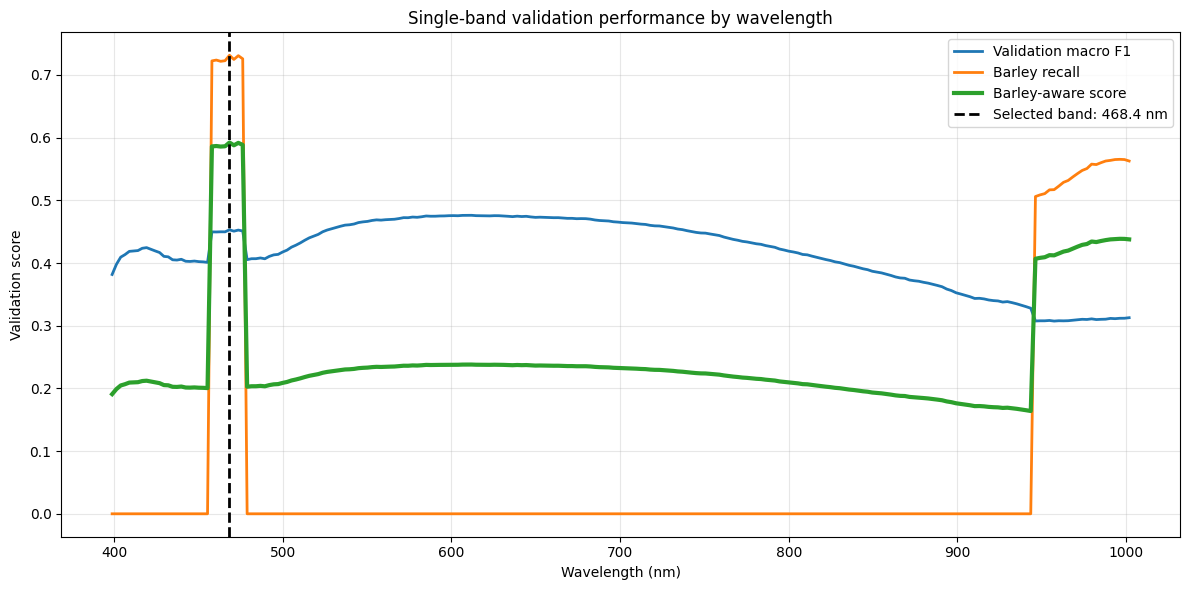

Selected single wavelength:
Band index: 27
Wavelength: 468.4 nm
Validation accuracy: 0.569
Validation macro F1: 0.453
Barley recall: 0.731
Barley-aware score: 0.592


In [21]:
# --- Plot single-band validation performance across wavelengths ---

plt.figure(figsize=(12, 6))

plt.plot(
    single_band_df["wavelength"],
    single_band_df["validation_macro_f1"],
    label="Validation macro F1",
    linewidth=2
)

plt.plot(
    single_band_df["wavelength"],
    single_band_df["barley_recall"],
    label="Barley recall",
    linewidth=2
)

plt.plot(
    single_band_df["wavelength"],
    single_band_df["barley_aware_score"],
    label="Barley-aware score",
    linewidth=3
)

best_row = single_band_df.sort_values(
    ["barley_aware_score", "validation_macro_f1", "validation_accuracy"],
    ascending=[False, False, False]
).iloc[0]

plt.axvline(
    best_row["wavelength"],
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Selected band: {best_row['wavelength']:.1f} nm"
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Validation score")
plt.title("Single-band validation performance by wavelength")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Selected single wavelength:")
print(f"Band index: {int(best_row['band_idx'])}")
print(f"Wavelength: {best_row['wavelength']:.1f} nm")
print(f"Validation accuracy: {best_row['validation_accuracy']:.3f}")
print(f"Validation macro F1: {best_row['validation_macro_f1']:.3f}")
print(f"Barley recall: {best_row['barley_recall']:.3f}")
print(f"Barley-aware score: {best_row['barley_aware_score']:.3f}")

In [22]:
# --- Save best single-band selection ---

selected_band_indices_best_single = np.array([int(best_row["band_idx"])])

np.save(
    "selected_band_indices_best_single.npy",
    selected_band_indices_best_single
)

print("Saved selected_band_indices_best_single.npy")
print("Best single band:", selected_band_indices_best_single[0])
print("Best single wavelength:", wavelengths[selected_band_indices_best_single[0]])

Saved selected_band_indices_best_single.npy
Best single band: 27
Best single wavelength: 468.35


In [19]:
selected_band_indices = ranked_band_indices

np.save("selected_band_indices_ipls.npy", selected_band_indices_ipls)
np.save("selected_band_indices_pca.npy", selected_band_indices)
np.save("selected_band_indices_vip.npy", ranked_band_indices_vip)
np.save("vip_scores.npy", vip_scores)
np.save("wavelengths.npy", wavelengths)

In [11]:
# --- Store PCA-ranked band indices for later PLS-DA / CNN experiments ---

selected_band_indices = ranked_band_indices

print("Total ranked bands:", len(selected_band_indices))
print("Top 10 selected band indices:", selected_band_indices[:10])
print("Top 10 selected wavelengths:", np.round(wavelengths[selected_band_indices[:10]], 1))

np.save("selected_band_indices_pca.npy", selected_band_indices)
np.save("wavelengths.npy", wavelengths)

Total ranked bands: 224
Top 10 selected band indices: [102 103 101 104 106 105 107 108 109 100]
Top 10 selected wavelengths: [668.8 671.5 666.  674.2 679.6 676.9 682.4 685.1 687.8 663.3]
